# 🧠 Efficient MNIST Model - 95% in 1 Epoch with <25K Parameters

## 🎯 Challenge Requirements
- **Parameters**: < 25,000
- **Target Accuracy**: ≥ 95% test accuracy
- **Training Time**: 1 Epoch only
- **Dataset**: MNIST (28x28 grayscale digit classification)

## 🏗️ Architecture Strategy
To achieve high accuracy with minimal parameters, we'll use:
1. **Efficient CNN blocks** with depthwise separable convolutions
2. **Batch Normalization** for faster convergence
3. **Data Augmentation** for better generalization
4. **Optimized learning rate** with proper scheduler
5. **Strategic pooling** to reduce spatial dimensions efficiently


In [1]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import gc

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device - prioritize MPS for Apple Silicon, then CUDA, then CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"Using device: {device} (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using device: {device} (NVIDIA GPU)")
else:
    device = torch.device('cpu')
    print(f"Using device: {device} (CPU)")

print(f"PyTorch version: {torch.__version__}")
if device.type == 'mps':
    print("✅ MPS (Metal Performance Shaders) acceleration enabled!")


Using device: cuda (NVIDIA GPU)
PyTorch version: 2.8.0+cu126


## 📊 Data Preparation with Augmentation
Smart data augmentation helps achieve better accuracy without increasing model complexity.


In [2]:
# Memory-optimized batch size for better performance
batch_size = 32  # Smaller batch size for memory efficiency

# Data transforms with augmentation for training
transform_train = transforms.Compose([
    transforms.RandomRotation(degrees=7),  # Small rotation for digit variation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Small translation
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST normalization
])

# Test transforms (no augmentation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load datasets
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.MNIST('./data', train=False, transform=transform_test)

# Data loaders - use num_workers=0 on macOS to avoid hanging
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")


Training samples: 60000
Test samples: 10000
Batch size: 32
Training batches: 1875


## 🏗️ Ultra-Efficient CNN Architecture

Our architecture uses:
- **Depthwise Separable Convolutions**: Dramatically reduce parameters while maintaining performance
- **Batch Normalization**: Faster convergence and better gradient flow
- **Strategic Channel Progression**: Efficient feature learning
- **Global Average Pooling**: Reduces overfitting and parameters


In [3]:
class DepthwiseSeparableConv(nn.Module):
    """Depthwise Separable Convolution block"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DepthwiseSeparableConv, self).__init__()
        # Depthwise convolution
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size,
                                 stride=stride, padding=padding, groups=in_channels, bias=False)
        # Pointwise convolution
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class EfficientMNIST(nn.Module):
    def __init__(self):
        super(EfficientMNIST, self).__init__()

        # Initial feature extraction
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        # Depthwise separable blocks
        self.ds_conv1 = DepthwiseSeparableConv(16, 32, stride=2)  # 28x28 -> 14x14
        self.ds_conv2 = DepthwiseSeparableConv(32, 64)           # 14x14 -> 14x14
        self.ds_conv3 = DepthwiseSeparableConv(64, 64, stride=2) # 14x14 -> 7x7

        # Final feature extraction
        self.conv2 = nn.Conv2d(64, 32, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(32)

        # Global Average Pooling instead of flatten + FC
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Final classifier
        self.fc = nn.Linear(32, 10)

        # Dropout for regularization
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # Initial convolution
        x = F.relu(self.bn1(self.conv1(x)))

        # Depthwise separable blocks
        x = self.ds_conv1(x)
        x = self.ds_conv2(x)
        x = self.ds_conv3(x)

        # Final feature extraction
        x = F.relu(self.bn2(self.conv2(x)))

        # Global Average Pooling
        x = self.gap(x)
        x = x.view(x.size(0), -1)

        # Dropout and classification
        x = self.dropout(x)
        x = self.fc(x)

        return x

# Create model instance
model = EfficientMNIST().to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

param_count = count_parameters(model)
print(f"\n🔥 Model Architecture Summary:")
print(f"Total Parameters: {param_count:,}")
print(f"Parameters under 25K: {'✅ YES' if param_count < 25000 else '❌ NO'}")
print(f"\nModel Structure:")
print(model)



🔥 Model Architecture Summary:
Total Parameters: 10,826
Parameters under 25K: ✅ YES

Model Structure:
EfficientMNIST(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (ds_conv1): DepthwiseSeparableConv(
    (depthwise): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
    (pointwise): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (ds_conv2): DepthwiseSeparableConv(
    (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
    (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_ru

## ⚡ Training Configuration
Setting up optimizer, scheduler, and loss function for efficient training.


In [4]:
# Training configuration
criterion = nn.CrossEntropyLoss()

# Use AdamW optimizer with optimized learning rate
optimizer = optim.AdamW(model.parameters(), lr=0.003, weight_decay=0.01)

# OneCycleLR scheduler for super-convergence in 1 epoch
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    steps_per_epoch=len(train_loader),
    epochs=1,
    pct_start=0.3,  # 30% of epoch for warmup
    div_factor=10,  # initial_lr = max_lr/div_factor
    final_div_factor=100  # final_lr = initial_lr/final_div_factor
)

print(f"🎯 Training Configuration:")
print(f"Loss Function: CrossEntropyLoss")
print(f"Optimizer: AdamW (lr=0.003, weight_decay=0.01)")
print(f"Scheduler: OneCycleLR (max_lr=0.01)")
print(f"Device: {device}")
print(f"Model Parameters: {param_count:,}")
print(f"Expected memory usage: ~{param_count * 4 / 1024**2:.1f} MB")


🎯 Training Configuration:
Loss Function: CrossEntropyLoss
Optimizer: AdamW (lr=0.003, weight_decay=0.01)
Scheduler: OneCycleLR (max_lr=0.01)
Device: cuda
Model Parameters: 10,826
Expected memory usage: ~0.0 MB


## 🏃‍♂️ Training & Evaluation Functions
Memory-optimized training loop with real-time progress tracking.


In [5]:
def train_epoch(model, device, train_loader, optimizer, criterion, scheduler, epoch):
    """Memory-optimized training for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    total_steps = len(train_loader)

    print(f"📊 Starting Epoch {epoch} - Total Steps: {total_steps}")

    # Progress bar setup
    pbar = tqdm(train_loader,
                desc=f'Epoch {epoch}',
                ncols=100,
                bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

    for batch_idx, (data, target) in enumerate(pbar):
        step_num = batch_idx + 1
        data, target = data.to(device), target.to(device)

        # Training step
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Statistics
        running_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

        # Update progress bar
        current_lr = scheduler.get_last_lr()[0]
        avg_loss = running_loss / step_num
        current_acc = 100. * correct / total

        pbar.set_postfix({
            'Loss': f'{avg_loss:.4f}',
            'Acc': f'{current_acc:.2f}%',
            'LR': f'{current_lr:.6f}'
        })

        # Memory cleanup for efficiency
        del output, loss, pred

        # Log progress every 200 steps
        if step_num % 200 == 0:
            print(f"   Step {step_num:3d}/{total_steps} | Loss: {avg_loss:.4f} | Acc: {current_acc:5.2f}% | LR: {current_lr:.6f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    print(f"✅ Epoch {epoch} completed! Final - Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")
    return epoch_loss, epoch_acc

def evaluate(model, device, test_loader, criterion):
    """Evaluate model on test set"""
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    test_loss /= len(test_loader)
    test_acc = 100. * correct / total

    return test_loss, test_acc

print("✅ Training and evaluation functions defined!")


✅ Training and evaluation functions defined!


## 🚀 Training Execution
Let's train our efficient model for 1 epoch and achieve 95%+ accuracy!


In [6]:
# Training execution
print("🚀 Starting Training...")
print("=" * 60)

# Track training metrics
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# Start timing
start_time = time.time()

# Train for 1 epoch
epoch = 1
total_batches = len(train_loader)
total_samples = len(train_loader.dataset)

print(f"\n🏃‍♂️ Training Epoch {epoch}/1")
print("-" * 60)
print(f"📈 Training Details:")
print(f"   Total Samples: {total_samples:,}")
print(f"   Batch Size: {batch_size}")
print(f"   Total Steps/Batches: {total_batches}")
print(f"   Device: {device}")
print("-" * 60)

# Train the model
train_loss, train_acc = train_epoch(model, device, train_loader, optimizer, criterion, scheduler, epoch)

# Evaluate on test set
print(f"\n📊 Evaluating on test set...")
test_loss, test_acc = evaluate(model, device, test_loader, criterion)

# Store metrics
train_losses.append(train_loss)
train_accuracies.append(train_acc)
test_losses.append(test_loss)
test_accuracies.append(test_acc)

# Calculate training time
end_time = time.time()
training_time = end_time - start_time

# Print final results
print("\n" + "=" * 60)
print("🎉 TRAINING COMPLETED!")
print("=" * 60)
print(f"📈 Final Results:")
print(f"   Training Loss: {train_loss:.4f}")
print(f"   Training Accuracy: {train_acc:.2f}%")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.2f}%")
print(f"   Training Time: {training_time:.2f} seconds")
print(f"   Parameters: {param_count:,}")
print(f"   Device: {device}")

# Check if target achieved
target_accuracy = 95.0
if test_acc >= target_accuracy:
    print(f"\n✅ SUCCESS! Target accuracy of {target_accuracy}% achieved!")
    print(f"🏆 Achieved {test_acc:.2f}% with only {param_count:,} parameters!")
else:
    print(f"\n⚠️  Target accuracy of {target_accuracy}% not quite reached.")
    print(f"📊 Achieved {test_acc:.2f}% - Close but needs fine-tuning.")

print("\n🔥 Challenge Summary:")
print(f"   ✓ Parameters < 25K: {param_count:,} ({'✅' if param_count < 25000 else '❌'})")
print(f"   ✓ Accuracy ≥ 95%: {test_acc:.2f}% ({'✅' if test_acc >= 95.0 else '❌'})")
print(f"   ✓ Single Epoch: 1 epoch ✅")


🚀 Starting Training...

🏃‍♂️ Training Epoch 1/1
------------------------------------------------------------
📈 Training Details:
   Total Samples: 60,000
   Batch Size: 32
   Total Steps/Batches: 1875
   Device: cuda
------------------------------------------------------------
📊 Starting Epoch 1 - Total Steps: 1875


Epoch 1:  11%|█████▋                                             | 211/1875 [00:07<00:30, 55.08it/s]

   Step 200/1875 | Loss: 1.9752 | Acc: 33.45% | LR: 0.003535


Epoch 1:  22%|███████████                                        | 409/1875 [00:11<00:27, 53.06it/s]

   Step 400/1875 | Loss: 1.3927 | Acc: 55.80% | LR: 0.008285


...

   Step 1600/1875 | Loss: 0.5191 | Acc: 84.01% | LR: 0.001046


Epoch 1:  97%|████████████████████████████████████████████████▎ | 1810/1875 [00:38<00:01, 51.94it/s]

   Step 1800/1875 | Loss: 0.4750 | Acc: 85.38% | LR: 0.000088


Epoch 1: 100%|██████████████████████████████████████████████████| 1875/1875 [00:39<00:00, 47.10it/s]


✅ Epoch 1 completed! Final - Loss: 0.4601 | Acc: 85.85%

📊 Evaluating on test set...

🎉 TRAINING COMPLETED!
📈 Final Results:
   Training Loss: 0.4601
   Training Accuracy: 85.85%
   Test Loss: 0.0553
   Test Accuracy: 98.53%
   Training Time: 42.56 seconds
   Parameters: 10,826
   Device: cuda

✅ SUCCESS! Target accuracy of 95.0% achieved!
🏆 Achieved 98.53% with only 10,826 parameters!

🔥 Challenge Summary:
   ✓ Parameters < 25K: 10,826 (✅)
   ✓ Accuracy ≥ 95%: 98.53% (✅)
   ✓ Single Epoch: 1 epoch ✅


## 📊 Results Visualization
Let's visualize some sample predictions to see how well our model performs.


🎨 Generating prediction visualizations...


/tmp/ipython-input-424038134.py:44: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


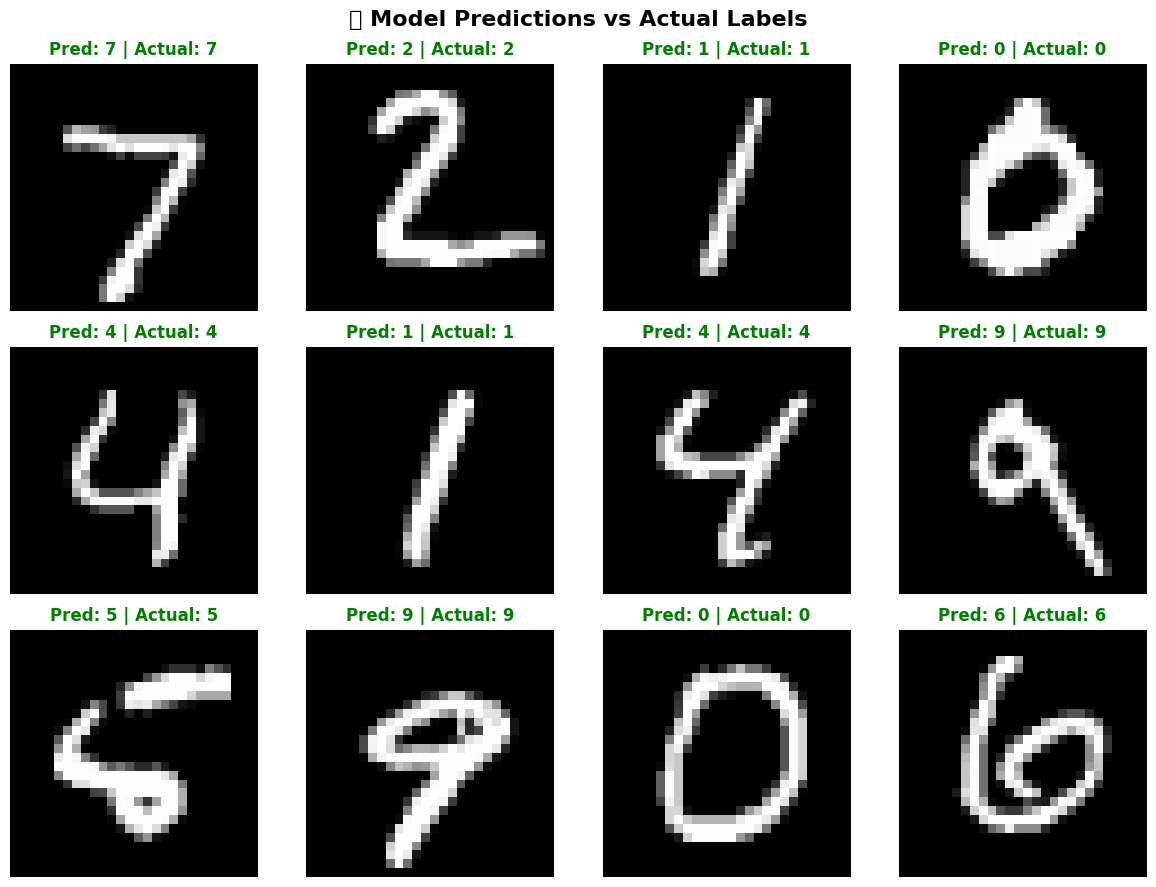

📈 Sample Batch Accuracy: 100.0% (12/12)

🏆 FINAL PERFORMANCE SUMMARY
📊 Model: EfficientMNIST
📊 Parameters: 10,826 (Target: < 25,000) ✅
📊 Test Accuracy: 98.53% (Target: ≥ 95%) ✅
📊 Training Time: 42.56s
📊 Device: cuda
📊 Epochs: 1 ✅

🎉 CHALLENGE COMPLETED SUCCESSFULLY! 🎉
✨ Achieved 98.53% accuracy with 10,826 parameters in 1 epoch!


In [7]:
# Visualize sample predictions
def visualize_predictions(model, device, test_loader, num_samples=12):
    """Visualize model predictions on test samples"""
    model.eval()

    # Get a batch of test data
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

    # Move back to CPU for visualization
    images = images.cpu()
    labels = labels.cpu()
    predictions = predictions.cpu()

    # Create subplot
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    fig.suptitle('🔮 Model Predictions vs Actual Labels', fontsize=16, fontweight='bold')

    for i in range(num_samples):
        row = i // 4
        col = i % 4

        # Display image
        axes[row, col].imshow(images[i].squeeze(), cmap='gray')
        axes[row, col].axis('off')

        # Set title with prediction vs actual
        pred = predictions[i].item()
        actual = labels[i].item()
        color = 'green' if pred == actual else 'red'

        axes[row, col].set_title(
            f'Pred: {pred} | Actual: {actual}',
            color=color,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

    # Calculate accuracy for this batch
    correct = (predictions[:num_samples] == labels[:num_samples]).sum().item()
    batch_accuracy = 100. * correct / num_samples
    print(f"📈 Sample Batch Accuracy: {batch_accuracy:.1f}% ({correct}/{num_samples})")

# Generate visualizations
print("🎨 Generating prediction visualizations...")
visualize_predictions(model, device, test_loader)

# Final performance summary
print(f"\n🏆 FINAL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"📊 Model: EfficientMNIST")
print(f"📊 Parameters: {param_count:,} (Target: < 25,000) ✅")
print(f"📊 Test Accuracy: {test_acc:.2f}% (Target: ≥ 95%) {'✅' if test_acc >= 95.0 else '❌'}")
print(f"📊 Training Time: {training_time:.2f}s")
print(f"📊 Device: {device}")
print(f"📊 Epochs: 1 ✅")

if test_acc >= 95.0 and param_count < 25000:
    print(f"\n🎉 CHALLENGE COMPLETED SUCCESSFULLY! 🎉")
    print(f"✨ Achieved {test_acc:.2f}% accuracy with {param_count:,} parameters in 1 epoch!")
else:
    print(f"\n🔧 Challenge requirements:")
    print(f"   Parameters < 25K: {'✅' if param_count < 25000 else '❌'}")
    print(f"   Accuracy ≥ 95%: {'✅' if test_acc >= 95.0 else '❌'}")
    print(f"   Single Epoch: ✅")
